In [ ]:
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
import plotly.express as px
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from numpy import asarray
from sklearn.ensemble import IsolationForest
import plotly.express as px

In [14]:
# аналогичным образом загружаем данные о пассажирах
passengers = pd.read_csv('data/passengers.csv')
# неподходящий формат данных приводим к тому, с которым Pandas может работать
passengers['Month'] = pd.to_datetime(passengers['Month'])
# также устанавливаем индекс и сортируем
df = passengers.set_index('Month').sort_index()

In [15]:
df

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


## Предсказание временного ряда с помощью деревьев

Попробуем обычное дерево решений и случайный лес, а потом сравним результаты

In [16]:
cols = []
for i in range(1, 0, -1):
    cols.append(df.shift(i))
cols

[            Passengers
 Month                 
 1949-01-01         NaN
 1949-02-01       112.0
 1949-03-01       118.0
 1949-04-01       132.0
 1949-05-01       129.0
 ...                ...
 1960-08-01       622.0
 1960-09-01       606.0
 1960-10-01       508.0
 1960-11-01       461.0
 1960-12-01       390.0
 
 [144 rows x 1 columns]]

In [17]:
cols = []
for i in range(1, 0, -1):
    cols.append(df.shift(i))
for i in range(0, 1):
    cols.append(df.shift(-i))
cols

[            Passengers
 Month                 
 1949-01-01         NaN
 1949-02-01       112.0
 1949-03-01       118.0
 1949-04-01       132.0
 1949-05-01       129.0
 ...                ...
 1960-08-01       622.0
 1960-09-01       606.0
 1960-10-01       508.0
 1960-11-01       461.0
 1960-12-01       390.0
 
 [144 rows x 1 columns],
             Passengers
 Month                 
 1949-01-01         112
 1949-02-01         118
 1949-03-01         132
 1949-04-01         129
 1949-05-01         121
 ...                ...
 1960-08-01         606
 1960-09-01         508
 1960-10-01         461
 1960-11-01         390
 1960-12-01         432
 
 [144 rows x 1 columns]]

In [18]:
agg = pd.concat(cols, axis=1)
agg.dropna(inplace=True)
agg

,Passengers,Passengers
Month,,
1949-02-01,112.0,118
1949-03-01,118.0,132
1949-04-01,132.0,129
1949-05-01,129.0,121
1949-06-01,121.0,135
...,...,...
1960-08-01,622.0,606
1960-09-01,606.0,508
1960-10-01,508.0,461


In [19]:
n_vars = 1 if type(df) is list else df.shape[1]
cols = []
for i in range(1, 0, -1):
    cols.append(df.shift(i))
for i in range(0, 1):
    cols.append(df.shift(-i))
# put it all together
agg = pd.concat(cols, axis=1)
agg.dropna(inplace=True)
list_for_forecast = agg.values

In [20]:
len(list_for_forecast)

143

In [21]:
def decision_tree_forecast(train, testX):
    train = asarray(train)
    trainX, trainy = train[:, :-1], train[:, -1]
    model = DecisionTreeRegressor(random_state=0)
    model.fit(trainX, trainy)
    yhat = model.predict([testX])
    return yhat[0]

In [22]:
def random_forest_forecast(train, testX):
    train = asarray(train)
    trainX, trainy = train[:, :-1], train[:, -1]
    model = RandomForestRegressor(n_estimators=1000)
    model.fit(trainX, trainy)
    yhat = model.predict([testX])
    return yhat[0]

In [23]:
predictions = []
size = int(len(list_for_forecast) * 0.66)
train, test = list_for_forecast[0:size], list_for_forecast[size:len(list_for_forecast)]
history = [x for x in train]
history

[array([112., 118.]),
 array([118., 132.]),
 array([132., 129.]),
 array([129., 121.]),
 array([121., 135.]),
 array([135., 148.]),
 array([148., 148.]),
 array([148., 136.]),
 array([136., 119.]),
 array([119., 104.]),
 array([104., 118.]),
 array([118., 115.]),
 array([115., 126.]),
 array([126., 141.]),
 array([141., 135.]),
 array([135., 125.]),
 array([125., 149.]),
 array([149., 170.]),
 array([170., 170.]),
 array([170., 158.]),
 array([158., 133.]),
 array([133., 114.]),
 array([114., 140.]),
 array([140., 145.]),
 array([145., 150.]),
 array([150., 178.]),
 array([178., 163.]),
 array([163., 172.]),
 array([172., 178.]),
 array([178., 199.]),
 array([199., 199.]),
 array([199., 184.]),
 array([184., 162.]),
 array([162., 146.]),
 array([146., 166.]),
 array([166., 171.]),
 array([171., 180.]),
 array([180., 193.]),
 array([193., 181.]),
 array([181., 183.]),
 array([183., 218.]),
 array([218., 230.]),
 array([230., 242.]),
 array([242., 209.]),
 array([209., 191.]),
 array([19

In [24]:
#train.dtype(list())

In [25]:
predictions = []
size = int(len(list_for_forecast) * 0.66)
train, test = list_for_forecast[0:size], list_for_forecast[size:len(list_for_forecast)]
history = [x for x in train]

for i in range(len(test)):
    testX, testy = test[i, :-1], test[i, -1]
    yhat = random_forest_forecast(history, testX)
    predictions.append(yhat)
    history.append(test[i])

error = mean_absolute_error(test[:, -1], predictions)
print("Random Forest error: ", error)

Random Forest error:  46.44976814868805


In [26]:
print("Random Forest metrics: ")
print("RMSE:", np.sqrt(mean_squared_error(test[:, -1], predictions)))
print("MAPE:", mean_absolute_percentage_error(test[:, -1], predictions))
print("MAE:", mean_absolute_error(test[:, -1], predictions))
print("R2: ", r2_score(test[:, -1], predictions))

Random Forest metrics: 
RMSE: 55.243078552313946
MAPE: 0.10918465479128688
MAE: 46.44976814868805
R2:  0.5030801559534797


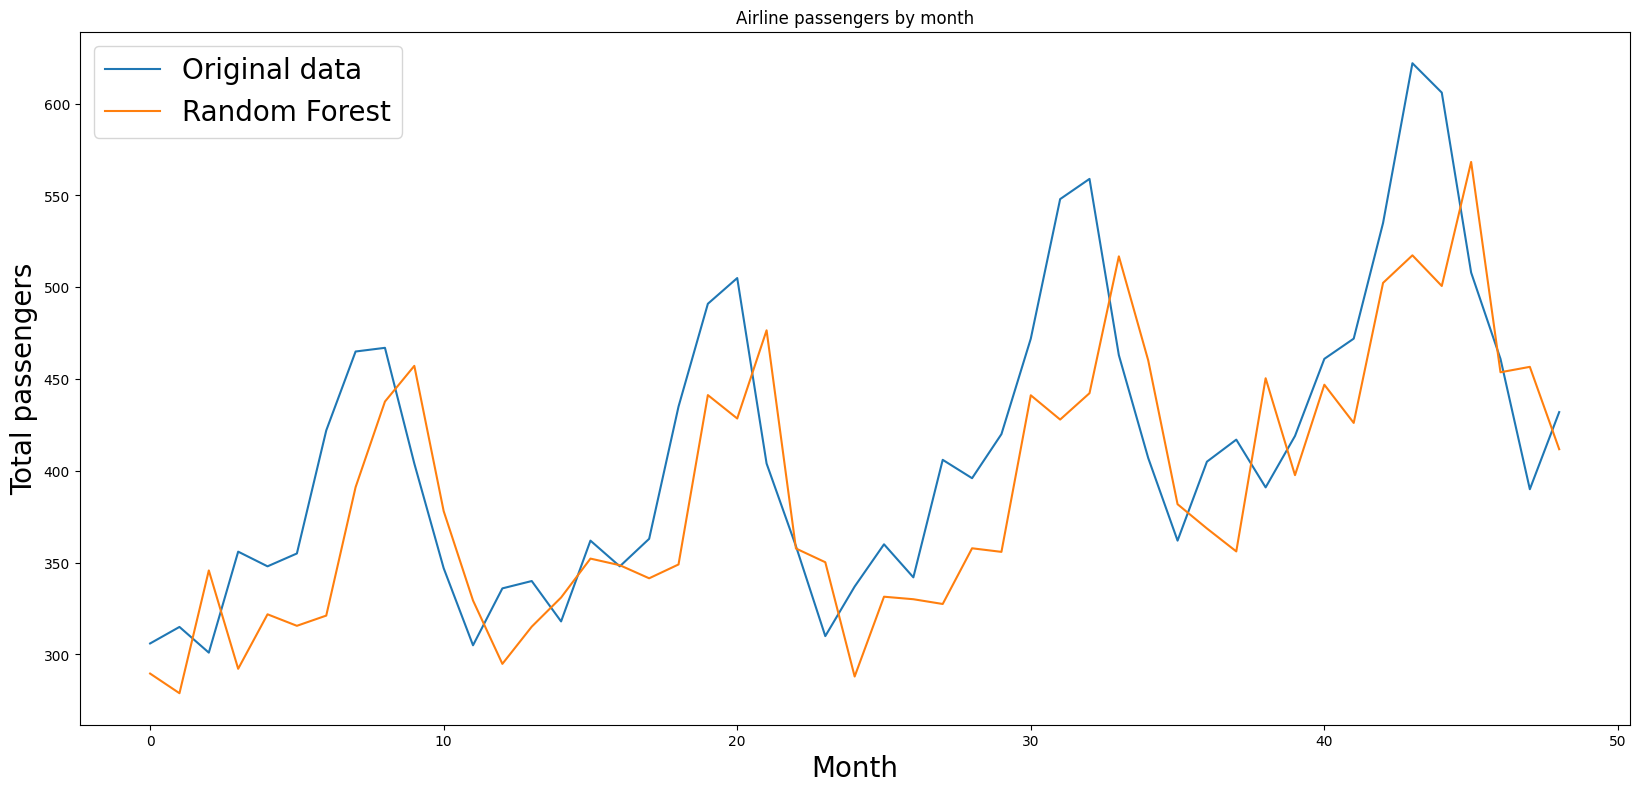

In [27]:
fig = plt.figure(figsize=(20, 9))
plt.plot(test[:, -1], label='Original data')
plt.plot(predictions, label='Random Forest')
plt.legend(fontsize="20")
plt.title('Airline passengers by month')
plt.ylabel('Total passengers', fontsize="20")
plt.xlabel('Month', fontsize="20")
plt.show()

In [28]:
predictions = list()
size = int(len(list_for_forecast) * 0.66)
train, test = list_for_forecast[0:size], list_for_forecast[size:len(list_for_forecast)]
history = [x for x in train]

for i in range(len(test)):
    testX, testy = test[i, :-1], test[i, -1]
    yhat = decision_tree_forecast(history, testX)
    predictions.append(yhat)
    history.append(test[i])


In [29]:
print("Decision Forest metrics: ")
print("RMSE:", np.sqrt(mean_squared_error(test[:, -1], predictions)))
print("MAPE:", mean_absolute_percentage_error(test[:, -1], predictions))
print("MAE:", mean_absolute_error(test[:, -1], predictions))
print("R2: ", r2_score(test[:, -1], predictions))

Decision Forest metrics: 
RMSE: 65.29403666867132
MAPE: 0.12270617535711836
MAE: 52.1530612244898
R2:  0.3058111520951716


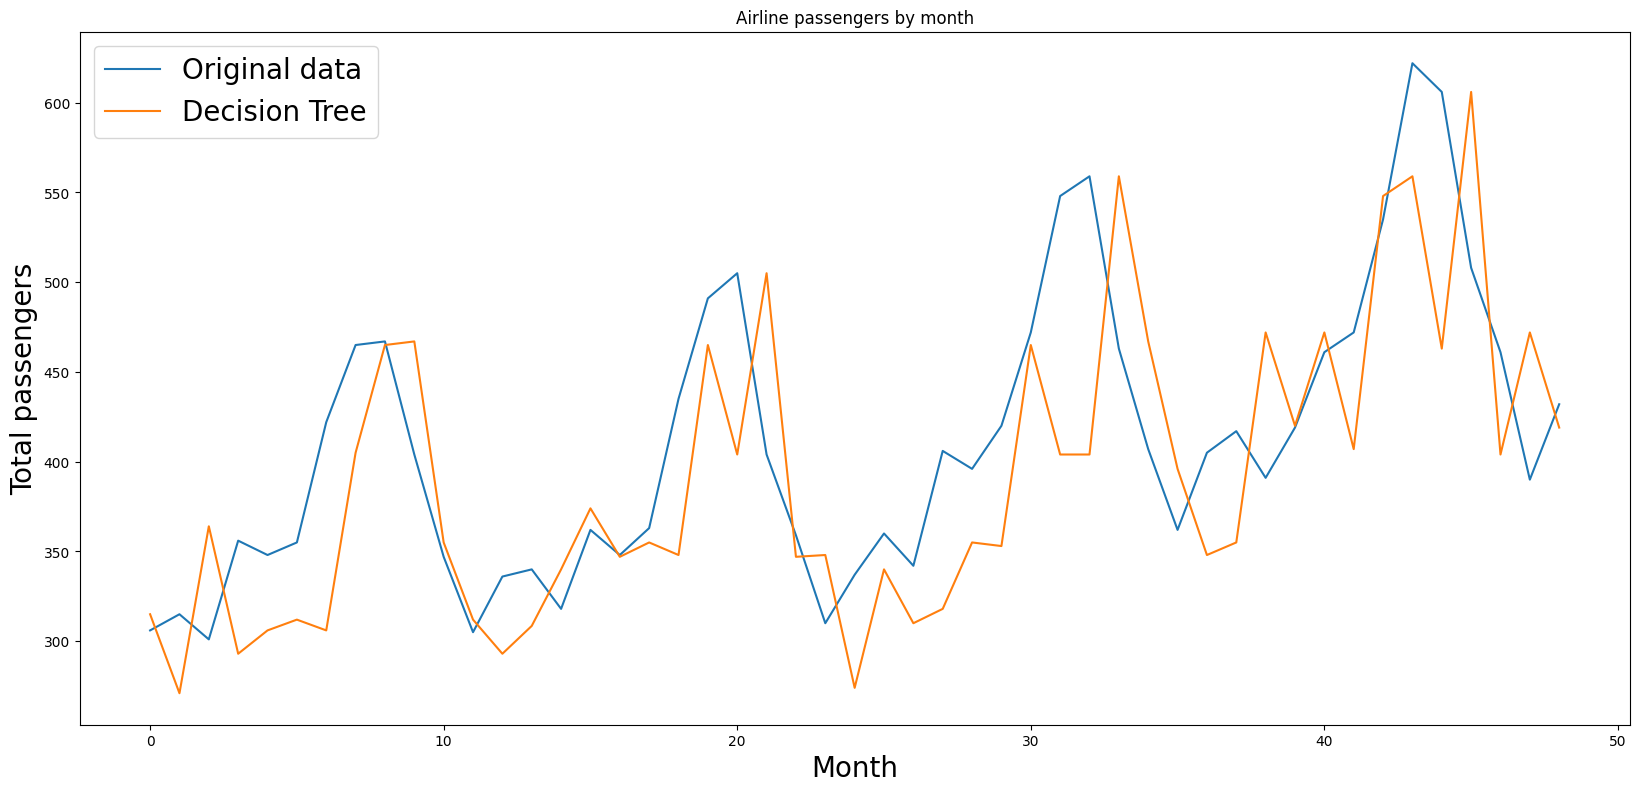

In [30]:
fig = plt.figure(figsize=(20, 9))
plt.plot(test[:, -1], label='Original data')
plt.plot(predictions, label='Decision Tree')
plt.legend(fontsize="20")
plt.title('Airline passengers by month')
plt.ylabel('Total passengers', fontsize="20")
plt.xlabel('Month', fontsize="20")
plt.show()

## Детекция аномалий с помощью isolated forest

In [31]:
from sklearn.ensemble import IsolationForest

In [32]:
# аналогичным образом загружаем данные о пассажирах
pas = pd.read_csv('data/passengers.csv')
# неподходящий формат данных приводим к тому, с которым Pandas может работать
pas['Month'] = pd.to_datetime(passengers['Month'])
# также устанавливаем индекс и сортируем
pas

,Month,Passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121
...,...,...
139,1960-08-01,606
140,1960-09-01,508
141,1960-10-01,461
142,1960-11-01,390


In [33]:
model = IsolationForest(contamination=0.004)
model.fit(pas[['Passengers']])

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.004
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",None
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [34]:
pas['outliers'] = pd.Series(model.predict(pas[['Passengers']])).apply(lambda x: 'yes' if (x == -1) else 'no' )

In [35]:
pas.query('outliers=="yes"')

,Month,Passengers,outliers
138,1960-07-01,622,yes


In [36]:
fig = px.scatter(pas.reset_index(), x='Month', y='Passengers', color='outliers')
fig.update_xaxes(
    rangeslider_visible=True,
)
fig.show()

## Самостоятельная работа

**Задание 1: Учет сезонности (больше лагов)**
В нашем прошлом примере мы брали сдвиг всего на один месяц (`lag = 1`). В данных авиаперевозок есть очевидная годовая сезонность.
Измените код так, чтобы модель смотрела на 12 предыдущих месяцев одновременно. Сформируйте выборку, обучите `RandomForest` с помощью функции `random_forest_forecast` и выведите метрики. Сравните, как изменились результаты.


In [ ]:
# 1. Формируем выборку с 12 лагами
cols_12 = []
for i in range(12, 0, -1):
    cols_12.append(df.shift(i))
cols_12.append(df)  # Целевая переменная (текущий месяц)

agg_12 = pd.concat(cols_12, axis=1)
agg_12.dropna(inplace=True)
list_for_forecast_12 = agg_12.values

# 2. Разделение и скользящий прогноз
predictions_12 = list()
size_12 = int(len(list_for_forecast_12) * 0.66)
train_12, test_12 = list_for_forecast_12[0:size_12], list_for_forecast_12[size_12:]
history_12 = [x for x in train_12]

for i in range(len(test_12)):
    testX_12, testy_12 = test_12[i, :-1], test_12[i, -1]
    yhat = random_forest_forecast(history_12, testX_12)
    predictions_12.append(yhat)
    history_12.append(test_12[i])

print("Random Forest (12 лагов) metrics:")
print(f"RMSE: {np.sqrt(mean_squared_error(test_12[:, -1], predictions_12)):.4f}")
print(f"MAE:  {mean_absolute_error(test_12[:, -1], predictions_12):.4f}")
print(f"MAPE: {mean_absolute_percentage_error(test_12[:, -1], predictions_12):.4f}")
print(f"R2:   {r2_score(test_12[:, -1], predictions_12):.4f}")

🌲 Random Forest (12 лагов) metrics:
RMSE: 33.5479
MAE:  26.6675
MAPE: 0.0627
R2:   0.8070


**Задание 2: Сравнение деревьев с «глупым» бейзлайном (Naive Forecast)**
Чтобы понимать, насколько вообще полезно применять Random Forest, нужен ориентир (baseline). Напишите простую «наивную» модель: в качестве прогноза на следующий шаг берется просто значение предыдущего шага ($\hat{y}_t = y_{t-1}$).
Сравните $R^2$ и $MAE$ наивного прогноза с вашим лесом из Задания 1.

In [ ]:
# Наивный прогноз
predictions_naive = [test_12[i][-2] for i in range(len(test_12))]

print("Naive Forecast (y_t = y_{t-1}) metrics:")
print(f"RMSE: {np.sqrt(mean_squared_error(test_12[:, -1], predictions_naive)):.4f}")
print(f"MAE:  {mean_absolute_error(test_12[:, -1], predictions_naive):.4f}")
print(f"MAPE: {mean_absolute_percentage_error(test_12[:, -1], predictions_naive):.4f}")
print(f"R2:   {r2_score(test_12[:, -1], predictions_naive):.4f}")

pd.DataFrame({
    'Модель': ['Random Forest (12 lag)', 'Naive Baseline'],
    'R2': [r2_score(test_12[:, -1], predictions_12), r2_score(test_12[:, -1], predictions_naive)],
    'MAE': [mean_absolute_error(test_12[:, -1], predictions_12), mean_absolute_error(test_12[:, -1], predictions_naive)]
})


📉 Naive Forecast (y_t = y_{t-1}) metrics:
RMSE: 48.8717
MAE:  40.9778
MAPE: 0.0975
R2:   0.5903


,Модель,R2,MAE
0,Random Forest (12 lag),0.806960,26.667511
1,Naive Baseline,0.590333,40.977778


**Задание 3: Чувствительность алгоритма поиска аномалий**
В конце практики мы использовали алгоритм `IsolationForest` для поиска аномалий с крайне низким параметром `contamination=0.004`.
Измените этот параметр на `0.05` (поиск 5% самых аномальных периодов), обучите модель заново и отрисуйте график с новыми подсвеченными точками. Как поменялась картина, какие теперь месяцы считаются "нетипичными"?


In [ ]:
pas = pd.read_csv('data/passengers.csv')
pas['Month'] = pd.to_datetime(pas['Month'])
model_05 = IsolationForest(contamination=0.05, random_state=42)
model_05.fit(pas[['Passengers']])

# Добавляем метки аномалий
pas['outliers_05'] = pd.Series(model_05.predict(pas[['Passengers']])).apply(lambda x: 'yes' if x == -1 else 'no')
print(pas.query('outliers_05 == "yes"'))

fig = px.scatter(pas.reset_index(), x='Month', y='Passengers', color='outliers_05',
                 color_discrete_map={'yes': '#EF553B', 'no': '#636EFA'})
fig.update_xaxes(rangeslider_visible=True)
fig.show()

         Month  Passengers outliers_05
10  1949-11-01         104         yes
114 1958-07-01         491         yes
126 1959-07-01         548         yes
127 1959-08-01         559         yes
137 1960-06-01         535         yes
138 1960-07-01         622         yes
139 1960-08-01         606         yes
140 1960-09-01         508         yes
